In [3]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import tqdm
import math
import sys
sys.path.append("/moao38_7/nunota/gapmoe/src/gapmoe/")
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
JD0 = 2450000

In [27]:
path_moa = "/moao38_7/nunota/HSC_FFP/colab_data/moa_magerror_clear.dat"
data_moa = np.genfromtxt(path_moa,names=["mag","med","ul","ll"],usecols=[0,1,2,3])

mag_vals_moa = data_moa['mag']
med_vals_moa = data_moa['med']
ul_vals_moa = data_moa['ul']
ll_vals_moa = data_moa['ll']

def get_mag_err_moa(mag):
    med_interp = np.interp(mag, mag_vals_moa, med_vals_moa)
    ul_interp = np.interp(mag, mag_vals_moa, ul_vals_moa)
    ll_interp = np.interp(mag, mag_vals_moa, ll_vals_moa)

    return med_interp,ul_interp,ll_interp

In [37]:
from matplotlib import rcParams
rcParams["font.size"] = 18
rcParams["axes.linewidth"] = 3
rcParams['xtick.top'] = True
rcParams['ytick.right'] = True
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['xtick.major.size'] = 10
rcParams['xtick.major.width'] = 1.5
rcParams['xtick.minor.size'] = 5
rcParams['xtick.minor.width'] = 1.5
rcParams['ytick.major.size'] = 10
rcParams['ytick.major.width'] = 1.5
rcParams['ytick.minor.size'] = 5
rcParams['ytick.minor.width'] = 1.5

In [38]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],  # デフォルトで matplotlib に入ってる serif フォント
    "mathtext.fontset": "cm",        # 数式を LaTeX っぽく
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

In [49]:
mag_plot = np.linspace(10,25,10000)
mag_err_plot_med, mag_err_plot_ll,mag_err_plot_ul= get_mag_err_moa(mag_plot)

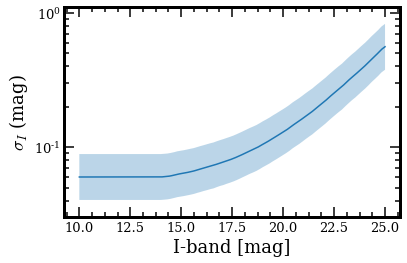

In [60]:
plt.plot(mag_plot,mag_err_plot_med*100)
plt.fill_between(mag_plot,mag_err_plot_ul*100,mag_err_plot_ll*100,alpha=0.3)

plt.ylabel(r"$\sigma_I$ (mag)",fontsize=18)
plt.xlabel("I-band [mag]",fontsize=18)
plt.minorticks_on()
plt.yscale("log")
plt.ylim(3e-2,1.1e0)
plt.tight_layout()
plt.savefig("../test_figures/magerr.pdf")
plt.show()